# 데이터 전처리

## 전처리 목표
1. 데이터 형식 통일 (amount 숫자 형식 통합, null값 처리)
2. 결측치 확인 및 처리 방안 수립 (age, gender, income)
3. 파싱 작업 (channels 컬럼, value 컬럼)
4. 컬럼 이름 통일 (customer_id)
5. amount 이상치 처리 (소수점 반올림, 분포 확인 후 이상치 제거)


## 1. 라이브러리 및 데이터 불러오기


In [1]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import ast
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 한글 제목/축이 깨지지 않도록 폰트 설정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
if os.name == 'nt':
    plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
else:
    plt.rcParams['font.family'] = ['AppleGothic', 'NanumGothic', 'sans-serif']  # Mac 등

# 데이터 경로: ../데이터셋 우선, 없으면 ../data / ../data/전처리_완료_데이터셋
DATA_DIR = "../데이터셋" if os.path.isdir("../데이터셋") else "../data"
CLEAN_DIR = "../데이터셋" if os.path.isdir("../데이터셋") else "../data/전처리_완료_데이터셋"
os.makedirs(CLEAN_DIR, exist_ok=True)
print("라이브러리 불러오기 완료")


라이브러리 불러오기 완료


In [2]:
# 데이터 불러오기
portfolio = pd.read_csv(os.path.join(DATA_DIR, "portfolio.csv"), encoding='utf-8-sig')
profile = pd.read_csv(os.path.join(DATA_DIR, "profile.csv"), encoding='utf-8-sig')
transcript = pd.read_csv(os.path.join(DATA_DIR, "transcript.csv"), encoding='utf-8-sig')

print("데이터 불러오기 완료")
print(f"Portfolio: {portfolio.shape}")
print(f"Profile: {profile.shape}")
print(f"Transcript: {transcript.shape}")


데이터 불러오기 완료
Portfolio: (10, 7)
Profile: (17000, 6)
Transcript: (306534, 5)


## 2. 컬럼 이름 통일 (customer_id)


In [3]:
# 컬럼 이름 통일
portfolio = portfolio.rename(columns={'id': 'offer_id'})
profile = profile.rename(columns={'id': 'customer_id'})
transcript = transcript.rename(columns={'person': 'customer_id'})

print("컬럼 이름 통일 완료")
print(f"\nPortfolio 컬럼: {portfolio.columns.tolist()}")
print(f"Profile 컬럼: {profile.columns.tolist()}")
print(f"Transcript 컬럼: {transcript.columns.tolist()}")


컬럼 이름 통일 완료

Portfolio 컬럼: ['Unnamed: 0', 'reward', 'channels', 'difficulty', 'duration', 'offer_type', 'offer_id']
Profile 컬럼: ['Unnamed: 0', 'gender', 'age', 'customer_id', 'became_member_on', 'income']
Transcript 컬럼: ['Unnamed: 0', 'customer_id', 'event', 'value', 'time']


## 3. Portfolio 데이터 전처리 - channels 컬럼 파싱


In [4]:
# channels 컬럼 확인
print("=== Channels 컬럼 샘플 ===")
print(portfolio['channels'].head())
print(f"\nChannels 데이터 타입: {type(portfolio['channels'].iloc[0])}")

# channels 컬럼을 파싱하여 개별 컬럼으로 변환
# 문자열 형태의 리스트를 실제 리스트로 변환
portfolio['channels_parsed'] = portfolio['channels'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# 모든 채널 종류 확인
all_channels = set()
for channels_list in portfolio['channels_parsed']:
    all_channels.update(channels_list)

print(f"\n모든 채널 종류: {sorted(all_channels)}")

# 각 채널에 대해 0/1 컬럼 생성
for channel in sorted(all_channels):
    portfolio[f'channel_{channel}'] = portfolio['channels_parsed'].apply(lambda x: 1 if channel in x else 0)

# 원본 channels와 channels_parsed 컬럼 제거 (또는 유지할 수도 있음)
# portfolio = portfolio.drop(columns=['channels', 'channels_parsed'])

print("\n=== Channels 파싱 완료 ===")
print(portfolio[['offer_id'] + [col for col in portfolio.columns if col.startswith('channel_')]].head())


=== Channels 컬럼 샘플 ===
0           ['email', 'mobile', 'social']
1    ['web', 'email', 'mobile', 'social']
2              ['web', 'email', 'mobile']
3              ['web', 'email', 'mobile']
4                        ['web', 'email']
Name: channels, dtype: object

Channels 데이터 타입: <class 'str'>

모든 채널 종류: ['email', 'mobile', 'social', 'web']

=== Channels 파싱 완료 ===
                           offer_id  channel_email  channel_mobile  \
0  ae264e3637204a6fb9bb56bc8210ddfd              1               1   
1  4d5c57ea9a6940dd891ad53e9dbe8da0              1               1   
2  3f207df678b143eea3cee63160fa8bed              1               1   
3  9b98b8c7a33c4b65b9aebfe6a799e6d9              1               1   
4  0b1e1539f2cc45b7b9fa7c272da2e1d7              1               0   

   channel_social  channel_web  
0               1            0  
1               1            1  
2               0            1  
3               0            1  
4               0            1  


## 4. Transcript 데이터 전처리 - value 컬럼 파싱


In [5]:
# value 컬럼 샘플 확인
print("=== Value 컬럼 샘플 ===")
print("Transaction 샘플:")
transaction_samples = transcript[transcript['event'] == 'transaction']['value'].head(5)
for idx, val in enumerate(transaction_samples):
    print(f"{idx}: {val}")

print("\nOffer 관련 샘플:")
offer_samples = transcript[transcript['event'] != 'transaction']['value'].head(5)
for idx, val in enumerate(offer_samples):
    print(f"{idx}: {val}")

# value 컬럼 파싱 함수
def parse_value(value_str):
    """
    value 컬럼을 파싱하여 offer_id와 amount를 추출
    """
    try:
        # 문자열 형태의 딕셔너리를 실제 딕셔너리로 변환
        value_dict = ast.literal_eval(value_str) if isinstance(value_str, str) else value_str
        
        # offer_id 추출 (키가 'offer id' 또는 'offer_id'일 수 있음)
        offer_id = value_dict.get('offer id') or value_dict.get('offer_id')
        
        # amount 추출
        amount = value_dict.get('amount')
        
        return pd.Series({'offer_id': offer_id, 'amount': amount})
    except:
        return pd.Series({'offer_id': None, 'amount': None})

# value 컬럼 파싱
value_parsed = transcript['value'].apply(parse_value)
transcript['offer_id'] = value_parsed['offer_id']
transcript['amount'] = value_parsed['amount']

print("\n=== Value 파싱 완료 ===")
print(f"offer_id null 개수: {transcript['offer_id'].isnull().sum()}")
print(f"amount null 개수: {transcript['amount'].isnull().sum()}")
print(f"\nEvent별 amount null 비율:")
print(transcript.groupby('event')['amount'].apply(lambda x: x.isnull().sum() / len(x) * 100))


=== Value 컬럼 샘플 ===
Transaction 샘플:
0: {'amount': 0.8300000000000001}
1: {'amount': 34.56}
2: {'amount': 13.23}
3: {'amount': 19.51}
4: {'amount': 18.97}

Offer 관련 샘플:
0: {'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'}
1: {'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'}
2: {'offer id': '2906b810c7d4411798c6938adc9daaa5'}
3: {'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'}
4: {'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'}

=== Value 파싱 완료 ===
offer_id null 개수: 138953
amount null 개수: 167581

Event별 amount null 비율:
event
offer completed    100.0
offer received     100.0
offer viewed       100.0
transaction          0.0
Name: amount, dtype: float64


## 5. Amount 데이터 형식 통일 및 처리


In [6]:
# amount 데이터 타입 확인
print("=== Amount 데이터 타입 확인 ===")
print(f"Amount 데이터 타입: {transcript['amount'].dtype}")
print(f"Amount null 개수: {transcript['amount'].isnull().sum()}")
print(f"Amount null 비율: {transcript['amount'].isnull().sum() / len(transcript) * 100:.2f}%")

# amount를 숫자형으로 변환
transcript['amount'] = pd.to_numeric(transcript['amount'], errors='coerce')

print(f"\n변환 후 Amount 데이터 타입: {transcript['amount'].dtype}")
print(f"변환 후 Amount null 개수: {transcript['amount'].isnull().sum()}")

# amount 샘플 확인 (소수점이 긴 값 확인)
print("\n=== Amount 샘플 (소수점 긴 값) ===")
sample_amounts = transcript['amount'].dropna().head(20)
for idx, amt in enumerate(sample_amounts):
    print(f"{idx}: {amt} (타입: {type(amt)})")


=== Amount 데이터 타입 확인 ===
Amount 데이터 타입: float64
Amount null 개수: 167581
Amount null 비율: 54.67%

변환 후 Amount 데이터 타입: float64
변환 후 Amount null 개수: 167581

=== Amount 샘플 (소수점 긴 값) ===
0: 0.8300000000000001 (타입: <class 'float'>)
1: 34.56 (타입: <class 'float'>)
2: 13.23 (타입: <class 'float'>)
3: 19.51 (타입: <class 'float'>)
4: 18.97 (타입: <class 'float'>)
5: 33.9 (타입: <class 'float'>)
6: 0.22 (타입: <class 'float'>)
7: 18.59 (타입: <class 'float'>)
8: 18.01 (타입: <class 'float'>)
9: 19.11 (타입: <class 'float'>)
10: 36.19 (타입: <class 'float'>)
11: 6.46 (타입: <class 'float'>)
12: 5.02 (타입: <class 'float'>)
13: 28.39 (타입: <class 'float'>)
14: 28.08 (타입: <class 'float'>)
15: 0.75 (타입: <class 'float'>)
16: 1.02 (타입: <class 'float'>)
17: 13.57 (타입: <class 'float'>)
18: 10.22 (타입: <class 'float'>)
19: 31.42 (타입: <class 'float'>)


In [7]:
# amount 소수점 반올림 (셋째 자리에서 반올림하여 둘째자리까지)
transcript['amount'] = transcript['amount'].round(2)

print("=== 소수점 반올림 완료 ===")
print(f"반올림 후 Amount 샘플:")
sample_amounts = transcript['amount'].dropna().head(10)
for idx, amt in enumerate(sample_amounts):
    print(f"{idx}: {amt}")


=== 소수점 반올림 완료 ===
반올림 후 Amount 샘플:
0: 0.83
1: 34.56
2: 13.23
3: 19.51
4: 18.97
5: 33.9
6: 0.22
7: 18.59
8: 18.01
9: 19.11


## 6. Amount 이상치 분석 및 처리


In [8]:
# transaction 이벤트의 amount만 확인 (구매 금액)
transaction_amounts = transcript[transcript['event'] == 'transaction']['amount'].dropna()

print("=== Transaction Amount 기본 통계 ===")
print(transaction_amounts.describe())

print(f"\n총 transaction 개수: {len(transaction_amounts)}")
print(f"Amount 범위: {transaction_amounts.min():.2f} ~ {transaction_amounts.max():.2f}")


=== Transaction Amount 기본 통계 ===
count    138953.000000
mean         12.777356
std          30.250529
min           0.050000
25%           2.780000
50%           8.890000
75%          18.070000
max        1062.280000
Name: amount, dtype: float64

총 transaction 개수: 138953
Amount 범위: 0.05 ~ 1062.28


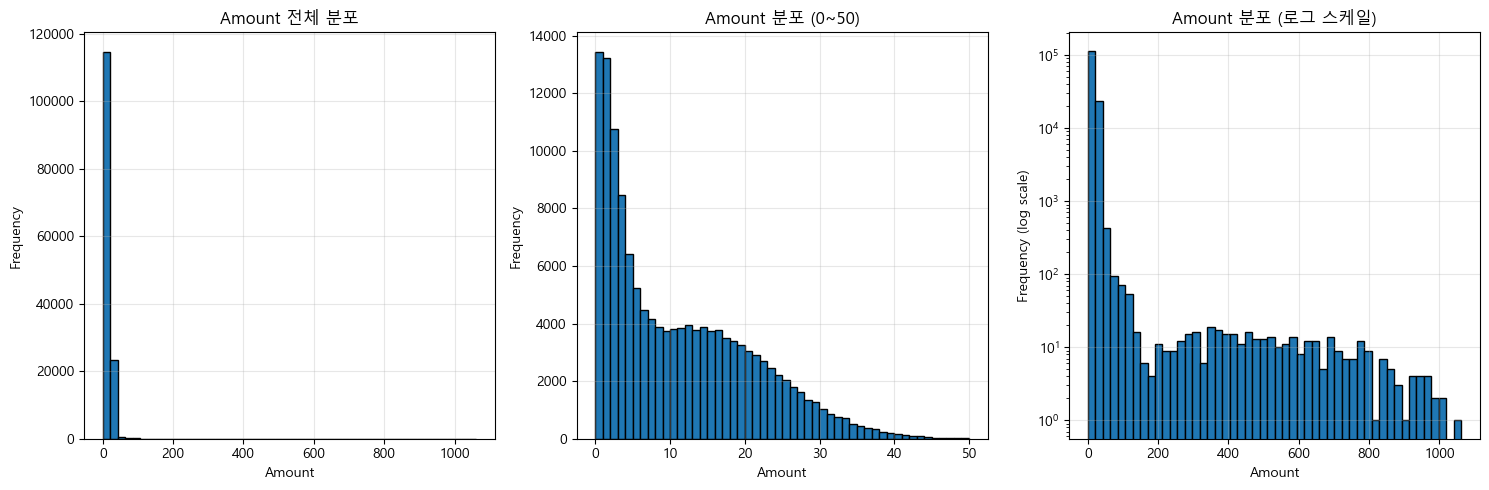

0~1 사이의 값 개수: 12715
1~5 사이의 값 개수: 39361
5~10 사이의 값 개수: 21574
10 이상의 값 개수: 65303


In [9]:
# Amount 분포 시각화 (히스토그램)
plt.figure(figsize=(15, 5))

# 전체 분포
plt.subplot(1, 3, 1)
plt.hist(transaction_amounts, bins=50, edgecolor='black')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.title('Amount 전체 분포')
plt.grid(True, alpha=0.3)

# 작은 값 집중 확인 (0 ~ 50)
plt.subplot(1, 3, 2)
small_amounts = transaction_amounts[transaction_amounts <= 50]
plt.hist(small_amounts, bins=50, edgecolor='black')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.title('Amount 분포 (0~50)')
plt.grid(True, alpha=0.3)

# 로그 스케일
plt.subplot(1, 3, 3)
plt.hist(transaction_amounts, bins=50, edgecolor='black')
plt.yscale('log')
plt.xlabel('Amount')
plt.ylabel('Frequency (log scale)')
plt.title('Amount 분포 (로그 스케일)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"0~1 사이의 값 개수: {((transaction_amounts >= 0) & (transaction_amounts < 1)).sum()}")
print(f"1~5 사이의 값 개수: {((transaction_amounts >= 1) & (transaction_amounts < 5)).sum()}")
print(f"5~10 사이의 값 개수: {((transaction_amounts >= 5) & (transaction_amounts < 10)).sum()}")
print(f"10 이상의 값 개수: {(transaction_amounts >= 10).sum()}")


In [10]:
# IQR 방법으로 이상치 확인
Q1 = transaction_amounts.quantile(0.25)
Q3 = transaction_amounts.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("=== IQR 기반 이상치 분석 ===")
print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower bound (Q1 - 1.5*IQR): {lower_bound:.2f}")
print(f"Upper bound (Q3 + 1.5*IQR): {upper_bound:.2f}")

outliers_iqr_lower = transaction_amounts[transaction_amounts < lower_bound]
outliers_iqr_upper = transaction_amounts[transaction_amounts > upper_bound]

print(f"IQR 기준 하한 이상치 개수: {len(outliers_iqr_lower)}")
print(f"IQR 기준 상한 이상치 개수: {len(outliers_iqr_upper)}")

if len(outliers_iqr_lower) > 0:
    print(f"하한 이상치 샘플 (상위 10개):")
    print(outliers_iqr_lower.sort_values().tail(10))


=== IQR 기반 이상치 분석 ===
Q1: 2.78
Q3: 18.07
IQR: 15.29
Lower bound (Q1 - 1.5*IQR): -20.16
Upper bound (Q3 + 1.5*IQR): 41.01
IQR 기준 하한 이상치 개수: 0
IQR 기준 상한 이상치 개수: 1236


In [11]:
# Z-score 방법으로 이상치 확인
z_scores = np.abs(stats.zscore(transaction_amounts))
outliers_zscore = transaction_amounts[z_scores > 3]

print("=== Z-score 기반 이상치 분석 (|z| > 3) ===")
print(f"Z-score 기준 이상치 개수: {len(outliers_zscore)}")
print(f"이상치 비율: {len(outliers_zscore) / len(transaction_amounts) * 100:.2f}%")

if len(outliers_zscore) > 0:
    print(f"\nZ-score 이상치 통계:")
    print(outliers_zscore.describe())
    
    # 작은 값과 큰 값 구분
    small_outliers = outliers_zscore[outliers_zscore < transaction_amounts.median()]
    large_outliers = outliers_zscore[outliers_zscore >= transaction_amounts.median()]
    
    print(f"\n작은 값 이상치 개수: {len(small_outliers)}")
    print(f"큰 값 이상치 개수: {len(large_outliers)}")


=== Z-score 기반 이상치 분석 (|z| > 3) ===
Z-score 기준 이상치 개수: 468
이상치 비율: 0.34%

Z-score 이상치 통계:
count     468.000000
mean      441.502500
std       241.041404
min       103.660000
25%       242.547500
50%       420.060000
75%       624.820000
max      1062.280000
Name: amount, dtype: float64

작은 값 이상치 개수: 0
큰 값 이상치 개수: 468


In [12]:
# 분포를 더 세세하게 확인하여 너무 작은 값만 이상치로 판단
# 백분위수 확인
print("=== Amount 백분위수 분석 ===")
percentiles = [0, 0.1, 0.5, 1, 2, 5, 10, 25, 50, 75, 90, 95, 98, 99, 99.5, 99.9, 100]
for p in percentiles:
    val = transaction_amounts.quantile(p / 100)
    print(f"{p:5.1f}%: {val:8.2f}")

# 매우 작은 값 확인 (보증금 가능성)
print("\n=== 매우 작은 값 확인 (0.5 미만) ===")
very_small = transaction_amounts[transaction_amounts < 0.5]
print(f"0.5 미만 값 개수: {len(very_small)}")
if len(very_small) > 0:
    print(f"샘플:")
    print(very_small.value_counts().sort_index().head(20))


=== Amount 백분위수 분석 ===
  0.0%:     0.05
  0.1%:     0.05
  0.5%:     0.08
  1.0%:     0.15
  2.0%:     0.28
  5.0%:     0.59
 10.0%:     1.08
 25.0%:     2.78
 50.0%:     8.89
 75.0%:    18.07
 90.0%:    25.49
 95.0%:    29.91
 98.0%:    35.41
 99.0%:    40.02
 99.5%:    50.41
 99.9%:   576.56
100.0%:  1062.28

=== 매우 작은 값 확인 (0.5 미만) ===
0.5 미만 값 개수: 5605
샘플:
amount
0.05    431
0.06    109
0.07     89
0.08    100
0.09     87
0.10     95
0.11     99
0.12     79
0.13     97
0.14    110
0.15    110
0.16    108
0.17    113
0.18    108
0.19    109
0.20    105
0.21    119
0.22    120
0.23    123
0.24    118
Name: count, dtype: int64


In [13]:
# 이상치 제거 기준: 눈으로 봤을 때도, IQR, Z-score 모두에서 이상치로 판단되는 값
# 요구사항: 너무 작은 값만 이상치로 판단하고 제거
# 보증금 가능성이 있는 매우 작은 값(예: 0.01~0.5) 제거 여부 결정

# 예시: 0.1 미만의 값 제거 (보증금으로 판단)
# 실제로는 분포를 보고 적절한 기준점을 선택해야 함
threshold = 0.1  # 이 값은 분포 분석 결과에 따라 조정 가능

outliers_small = transaction_amounts[transaction_amounts < threshold]
print(f"=== {threshold} 미만 값 분석 ===")
print(f"{threshold} 미만 값 개수: {len(outliers_small)}")
print(f"비율: {len(outliers_small) / len(transaction_amounts) * 100:.2f}%")

if len(outliers_small) > 0:
    print(f"\n값 분포:")
    print(outliers_small.value_counts().sort_index())

# 이상치 제거 (선택 사항 - 주석 처리 후 필요시 사용)
# transcript_clean = transcript[
#     ~((transcript['event'] == 'transaction') & (transcript['amount'] < threshold))
# ].copy()

print("\n※ 이상치 제거는 분포 분석 결과를 바탕으로 적절한 기준점을 선택한 후 진행하세요.")


=== 0.1 미만 값 분석 ===
0.1 미만 값 개수: 816
비율: 0.59%

값 분포:
amount
0.05    431
0.06    109
0.07     89
0.08    100
0.09     87
Name: count, dtype: int64

※ 이상치 제거는 분포 분석 결과를 바탕으로 적절한 기준점을 선택한 후 진행하세요.


In [14]:
# Amount 큰 값 이상치 제거 (Z-score 기준)
# 팀미팅 요구사항: 큰 값 → Zscore 제거 (|z| > 3)

print("=== Amount 큰 값 Z-score 이상치 제거 ===")

# transaction 이벤트의 amount만 이상치 제거 대상
transaction_mask = transcript['event'] == 'transaction'
transaction_amounts_before = transcript.loc[transaction_mask, 'amount'].dropna()

if len(transaction_amounts_before) > 0:
    # Z-score 계산
    z_scores = np.abs(stats.zscore(transaction_amounts_before))
    outlier_mask = z_scores > 3
    
    # 이상치가 있는 행의 인덱스
    outlier_indices = transaction_amounts_before[outlier_mask].index
    
    print(f"제거 전 transaction 개수: {len(transaction_amounts_before):,}건")
    print(f"Z-score > 3인 이상치 개수: {len(outlier_indices):,}건")
    print(f"이상치 비율: {len(outlier_indices) / len(transaction_amounts_before) * 100:.2f}%")
    
    if len(outlier_indices) > 0:
        print(f"\n제거되는 이상치 통계:")
        outliers_removed = transaction_amounts_before.loc[outlier_indices]
        print(outliers_removed.describe())
        
        # 이상치 제거
        transcript = transcript.drop(outlier_indices)
        
        # 제거 후 통계
        transaction_amounts_after = transcript.loc[transcript['event'] == 'transaction', 'amount'].dropna()
        print(f"\n제거 후 transaction 개수: {len(transaction_amounts_after):,}건")
        print(f"제거된 행 수: {len(transaction_amounts_before) - len(transaction_amounts_after):,}건")
        print(f"전체 transcript 행 수: {len(transcript):,}건")
    else:
        print("\n제거할 이상치가 없습니다.")
else:
    print("Transaction 데이터가 없습니다.")



=== Amount 큰 값 Z-score 이상치 제거 ===
제거 전 transaction 개수: 138,953건
Z-score > 3인 이상치 개수: 468건
이상치 비율: 0.34%

제거되는 이상치 통계:
count     468.000000
mean      441.502500
std       241.041404
min       103.660000
25%       242.547500
50%       420.060000
75%       624.820000
max      1062.280000
Name: amount, dtype: float64

제거 후 transaction 개수: 138,485건
제거된 행 수: 468건
전체 transcript 행 수: 306,066건


## 7. 결측치 확인 (Profile 데이터 - age, gender, income)


In [15]:
# Profile 데이터 결측치 확인
print("=== Profile 데이터 결측치 확인 ===")
missing_profile = profile.isnull().sum()
missing_profile_pct = (profile.isnull().sum() / len(profile) * 100).round(2)

missing_df = pd.DataFrame({
    '결측치 개수': missing_profile,
    '결측치 비율(%)': missing_profile_pct
})

print(missing_df[missing_df['결측치 개수'] > 0])

# age, gender, income이 모두 null인 행 확인
profile_all_null = profile[
    profile['age'].isnull() | 
    profile['gender'].isnull() | 
    profile['income'].isnull()
]
print(f"\nage, gender, income 중 하나라도 null인 행 개수: {len(profile_all_null)}")

# age=118인 경우 확인 (이전 분석에서 age=118일 때 gender, income이 null임을 확인)
profile_age118 = profile[profile['age'] == 118]
print(f"\nage=118인 행 개수: {len(profile_age118)}")
print(f"age=118인 행의 gender null: {profile_age118['gender'].isnull().sum()}")
print(f"age=118인 행의 income null: {profile_age118['income'].isnull().sum()}")

print("\n※ 결측치 처리 방안:")
print("- age, gender, income이 null인 2175건에 대해 일단 유지")
print("- EDA 후 결정 예정")
print("- 조인 시 약 1000건 정도의 transaction 데이터가 삭제될 것으로 예상 (약 3만건 중)")


=== Profile 데이터 결측치 확인 ===
        결측치 개수  결측치 비율(%)
gender    2175      12.79
income    2175      12.79

age, gender, income 중 하나라도 null인 행 개수: 2175

age=118인 행 개수: 2175
age=118인 행의 gender null: 2175
age=118인 행의 income null: 2175

※ 결측치 처리 방안:
- age, gender, income이 null인 2175건에 대해 일단 유지
- EDA 후 결정 예정
- 조인 시 약 1000건 정도의 transaction 데이터가 삭제될 것으로 예상 (약 3만건 중)


## 8. 데이터 전처리 완료 확인


In [16]:
# 전처리된 데이터 확인
print("=== 전처리 완료 데이터 요약 ===")
print(f"\n1. Portfolio 데이터:")
print(f"   Shape: {portfolio.shape}")
print(f"   컬럼: {portfolio.columns.tolist()}")

print(f"\n2. Profile 데이터:")
print(f"   Shape: {profile.shape}")
print(f"   컬럼: {profile.columns.tolist()}")
print(f"   결측치: age/gender/income null 행 {len(profile[profile['age'].isnull() | profile['gender'].isnull() | profile['income'].isnull()])}건")

print(f"\n3. Transcript 데이터:")
print(f"   Shape: {transcript.shape}")
print(f"   컬럼: {transcript.columns.tolist()}")
print(f"   amount null: {transcript['amount'].isnull().sum()}건")
print(f"   offer_id null: {transcript['offer_id'].isnull().sum()}건")

# 채널 컬럼 확인
channel_cols = [col for col in portfolio.columns if col.startswith('channel_')]
print(f"\n4. Portfolio Channels 파싱:")
print(f"   채널 컬럼: {channel_cols}")
print(portfolio[['offer_id'] + channel_cols].head())

# value 파싱 확인
print(f"\n5. Transcript Value 파싱 샘플:")
print(transcript[['customer_id', 'event', 'offer_id', 'amount', 'time']].head(10))


=== 전처리 완료 데이터 요약 ===

1. Portfolio 데이터:
   Shape: (10, 12)
   컬럼: ['Unnamed: 0', 'reward', 'channels', 'difficulty', 'duration', 'offer_type', 'offer_id', 'channels_parsed', 'channel_email', 'channel_mobile', 'channel_social', 'channel_web']

2. Profile 데이터:
   Shape: (17000, 6)
   컬럼: ['Unnamed: 0', 'gender', 'age', 'customer_id', 'became_member_on', 'income']
   결측치: age/gender/income null 행 2175건

3. Transcript 데이터:
   Shape: (306066, 7)
   컬럼: ['Unnamed: 0', 'customer_id', 'event', 'value', 'time', 'offer_id', 'amount']
   amount null: 167581건
   offer_id null: 138485건

4. Portfolio Channels 파싱:
   채널 컬럼: ['channel_email', 'channel_mobile', 'channel_social', 'channel_web']
                           offer_id  channel_email  channel_mobile  \
0  ae264e3637204a6fb9bb56bc8210ddfd              1               1   
1  4d5c57ea9a6940dd891ad53e9dbe8da0              1               1   
2  3f207df678b143eea3cee63160fa8bed              1               1   
3  9b98b8c7a33c4b65b9aebfe6a799e6

## 9. 전처리된 데이터 저장 (선택 사항)

전처리된 데이터를 저장하려면 아래 셀의 주석을 해제하고 실행하세요.


In [17]:
# 전처리된 데이터 저장 (clean 파일로 저장)
portfolio.to_csv(os.path.join(CLEAN_DIR, "portfolio_clean.csv"), index=False, encoding='utf-8-sig')
# profile은 원본 그대로 사용하므로 저장하지 않음
transcript.to_csv(os.path.join(CLEAN_DIR, "transcript_clean.csv"), index=False, encoding='utf-8-sig')

print("전처리된 데이터 저장 완료")
print(f"Portfolio 저장: portfolio_clean.csv")
print(f"Transcript 저장: transcript_clean.csv (Z-score 이상치 제거 포함)")

전처리된 데이터 저장 완료
Portfolio 저장: portfolio_clean.csv
Transcript 저장: transcript_clean.csv (Z-score 이상치 제거 포함)
